In [1]:
# Trajectory sampler
# ================================
# This section performs sampling of the original descriptors matrix or reduced ones from dim_red.ipynb to generate an initial dataset


In [1]:
import os, glob, json
import numpy as np
import pandas as pd
from sampler import sample, atoms_to_structures, load_reduced, pc_coverage_bins
from dim_red_utils import load_pca_model
import matplotlib.pyplot as plt

In [3]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True 
if embedded_file:
    # Look for .npy file in embedding/ directory
    npy_files = glob.glob("embedding/*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/ directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")

    X = load_reduced(npy_file)  # or use np.load directly
    print("Loaded embedding with shape:", X.shape)

    pca_model_file = glob.glob("embedding/*.json") 
    if not pca_model_file:
        raise FileNotFoundError("No PCA model .json file found in embedding/ directory")
    if len(pca_model_file) > 1:
        raise RuntimeError(f"Multiple PCA model files found: {pca_model_file}")
    pca_model_file = pca_model_file[0]
    print(f"Using PCA model: {pca_model_file}")
    pca_model = load_pca_model(pca_model_file)
    
else: 
    # Look for .npy file in current directory
    npy_files = glob.glob("./*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")

# Find provenance parquet file
parquet_files = glob.glob("*.parquet")
if not parquet_files:
    raise FileNotFoundError("No provenance .parquet file found in current directory")
if len(parquet_files) > 1:
    raise RuntimeError(f"Multiple parquet files found: {parquet_files}")
parquet_file = parquet_files[0]
print(f"Using provenance file: {parquet_file}")
meta = pd.read_parquet(parquet_file)

# Match corresponding JSON file with same timestamp
json_file = glob.glob("*.json")
if not json_file:
    raise FileNotFoundError(f"No filemap JSON found")
if len(json_file) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_file}")
json_file = json_file[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

    

Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (11552338, 4)
Using PCA model: embedding/pca_model.json
Using provenance file: SOAP_O-N-C_provenance_20250917-112705.parquet
Using filemap: SOAP_O-N-C_filemap_20250917-112705.json


In [4]:
print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

X dtype/shape: float64 (11552338, 4)
has_nan: False has_inf: False abs max: 41.431714955625324


## FPS sampling

Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 999/999 [01:57<00:00,  8.51it/s]


Mean coverage: 0.019229999999999997


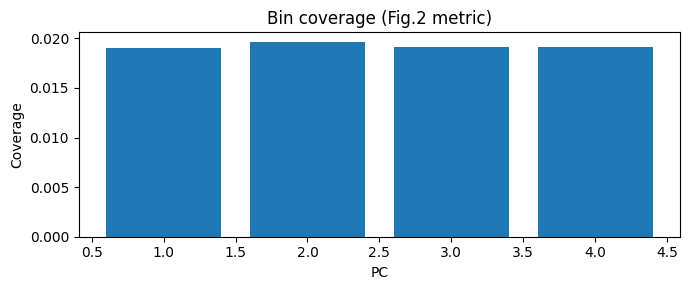

In [15]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="fps"
idx_atoms = sample(X, method=method, k=1000, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")#choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(f"sampled_atom_indices_{method}.npy", idx_atoms)
chosen_structs.to_csv(f"sampled_structures_{method}.csv", index=False)

per_pc, mean_cov = pc_coverage_bins(X, idx_atoms, nbins=50000)
print("Mean coverage:", mean_cov)

m = min(4, X.shape[1])
plt.figure(figsize=(7,3))
plt.bar(range(1, m+1), per_pc[:m])
plt.xlabel("PC"); plt.ylabel("Coverage"); plt.title("Bin coverage (Fig.2 metric)")
plt.tight_layout(); plt.show()

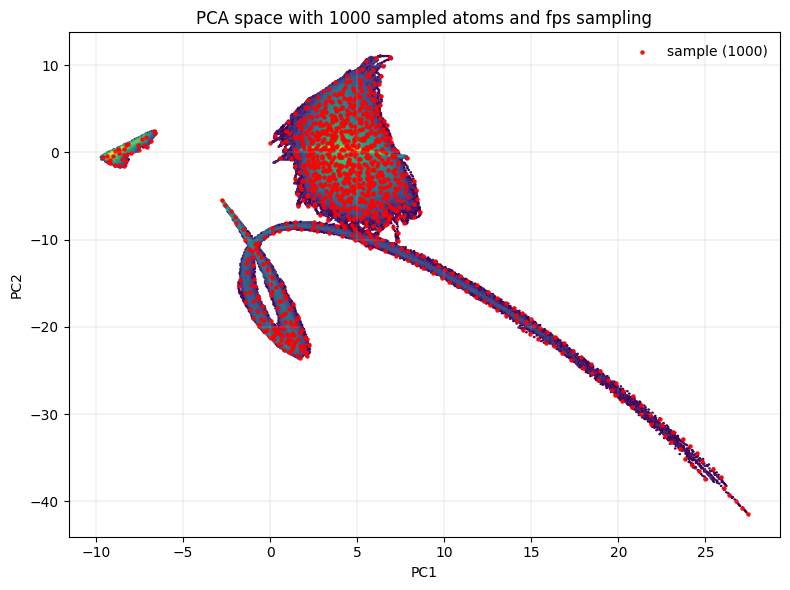

In [6]:
# Guard: only plot if this is a PCA embedding (file name contains "pca")
is_pca = ("pca" in os.path.basename(npy_file).lower()) and (X.shape[1] >= 2)
if not is_pca:
    raise RuntimeError("Plotting requires a 2D+ PCA embedding. Load a PCA .npy first.")

# idx_atoms must come from your sampler, e.g.:
# method = "fps"; idx_atoms = sample(X, method=method, k=1000, progress=True)

fig, ax = plt.subplots(figsize=(8,6))

N = X.shape[0]
if N > 2_000_000:
    # faster background for huge N
    hb = ax.hexbin(X[:,0], X[:,1], gridsize=500, bins='log')
else:
    ax.scatter(X[:,0], X[:,1], s=1, alpha=0.05)

# overlay sampled points
ax.scatter(X[idx_atoms,0], X[idx_atoms,1], s=5, alpha=0.9, c='r', marker='o', label=f"sample ({len(idx_atoms)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA space with {len(idx_atoms)} sampled atoms and {method} sampling")
ax.grid(True, linewidth=0.2)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

## Random sampling

Using random sampling ...
Mean coverage: 0.017455000000000002


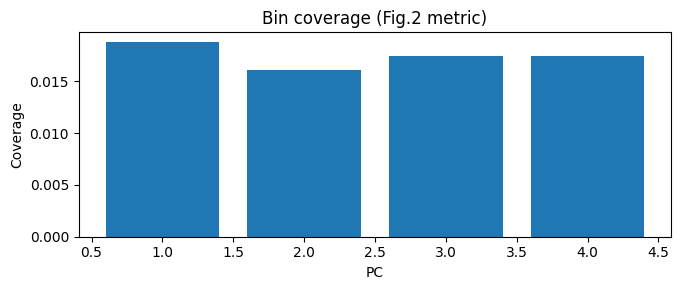

In [14]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="random"
idx_atoms = sample(X, method=method, seed=42, k=1000, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all") #choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(f"sampled_atom_indices_{method}.npy", idx_atoms)
chosen_structs.to_csv(f"sampled_structures_{method}.csv", index=False)

per_pc, mean_cov = pc_coverage_bins(X, idx_atoms, nbins=50000)
print("Mean coverage:", mean_cov)

m = min(4, X.shape[1])
plt.figure(figsize=(7,3))
plt.bar(range(1, m+1), per_pc[:m])
plt.xlabel("PC"); plt.ylabel("Coverage"); plt.title("Bin coverage (Fig.2 metric)")
plt.tight_layout(); plt.show()

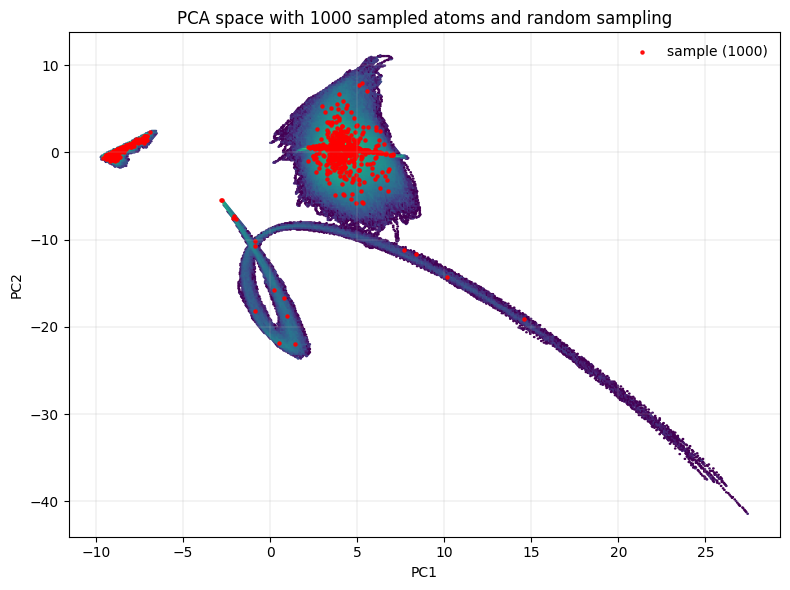

In [8]:
# Guard: only plot if this is a PCA embedding (file name contains "pca")
is_pca = ("pca" in os.path.basename(npy_file).lower()) and (X.shape[1] >= 2)
if not is_pca:
    raise RuntimeError("Plotting requires a 2D+ PCA embedding. Load a PCA .npy first.")

# idx_atoms must come from your sampler, e.g.:
# method = "fps"; idx_atoms = sample(X, method=method, k=1000, progress=True)

fig, ax = plt.subplots(figsize=(8,6))

N = X.shape[0]
if N > 2_000_000:
    # faster background for huge N
    hb = ax.hexbin(X[:,0], X[:,1], gridsize=500, bins='log')
else:
    ax.scatter(X[:,0], X[:,1], s=1, alpha=0.05)

# overlay sampled points
ax.scatter(X[idx_atoms,0], X[idx_atoms,1], s=5, alpha=0.9, c='r', marker='o', label=f"sample ({len(idx_atoms)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA space with {len(idx_atoms)} sampled atoms and {method} sampling")
ax.grid(True, linewidth=0.2)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

## HDBSCAN

In [10]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="hdbscan"

idx = sample(X, method=method, k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(f"sampled_atom_indices_{method}.npy", idx_atoms)
chosen_structs.to_csv(f"sampled_structures_{method}.csv", index=False)

per_pc, mean_cov = pc_coverage_bins(X, idx_atoms, nbins=50000)
print("Mean coverage:", mean_cov)

m = min(4, X.shape[1])
plt.figure(figsize=(7,3))
plt.bar(range(1, m+1), per_pc[:m])
plt.xlabel("PC"); plt.ylabel("Coverage"); plt.title("Bin coverage (Fig.2 metric)")
plt.tight_layout(); plt.show()

Using HDBSCAN medoids sampling ...


/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Guard: only plot if this is a PCA embedding (file name contains "pca")
is_pca = ("pca" in os.path.basename(npy_file).lower()) and (X.shape[1] >= 2)
if not is_pca:
    raise RuntimeError("Plotting requires a 2D+ PCA embedding. Load a PCA .npy first.")

# idx_atoms must come from your sampler, e.g.:
# method = "fps"; idx_atoms = sample(X, method=method, k=1000, progress=True)

fig, ax = plt.subplots(figsize=(8,6))

N = X.shape[0]
if N > 2_000_000:
    # faster background for huge N
    hb = ax.hexbin(X[:,0], X[:,1], gridsize=500, bins='log')
else:
    ax.scatter(X[:,0], X[:,1], s=1, alpha=0.05)

# overlay sampled points
ax.scatter(X[idx_atoms,0], X[idx_atoms,1], s=5, alpha=0.9, c='r', marker='o', label=f"sample ({len(idx_atoms)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA space with {len(idx_atoms)} sampled atoms and {method} sampling")
ax.grid(True, linewidth=0.2)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

## BIRCH

In [11]:
# inputs: PCA embedding Z (all rows), explained_variance EV (from your saved JSON)
from sampler import direct_birch_sample, pc_bin_coverage

idx, info = direct_birch_sample(
    Z_pca=X, ev=pca_model.explained_variance_,
    n_clusters=50,          # or None → CF subclusters
    threshold=0.5,
    branching_factor=50,
    k_per_cluster=20,
    progress=True
)
print(info)

# lift to structures with your existing atoms_to_structures(...)
chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

# save
method="birch"
np.save(f"sampled_atom_indices_{method}.npy", idx)
chosen_structs.to_csv(f"sampled_structures_{method}.csv", index=False)



Stratified pick: 100%|██████████| 50/50 [00:01<00:00, 40.99it/s]


{'n_clusters': 50, 'k_per_cluster': 20, 'selected': 1000, 'threshold': 0.5, 'branching_factor': 50}


Mean bin coverage: 0.01932


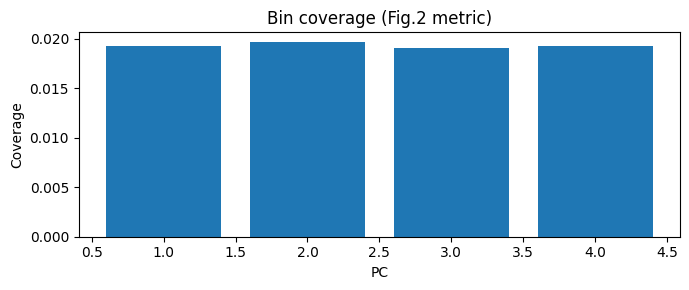

In [12]:
# coverage like Fig. 2(d)
per_pc, mean_cov = pc_bin_coverage(X, idx, nbins=50000)
print("Mean bin coverage:", mean_cov)

m = min(4, X.shape[1])
plt.figure(figsize=(7,3))
plt.bar(range(1, m+1), per_pc[:m])
plt.xlabel("PC"); plt.ylabel("Coverage"); plt.title("Bin coverage (Fig.2 metric)")
plt.tight_layout(); plt.show()

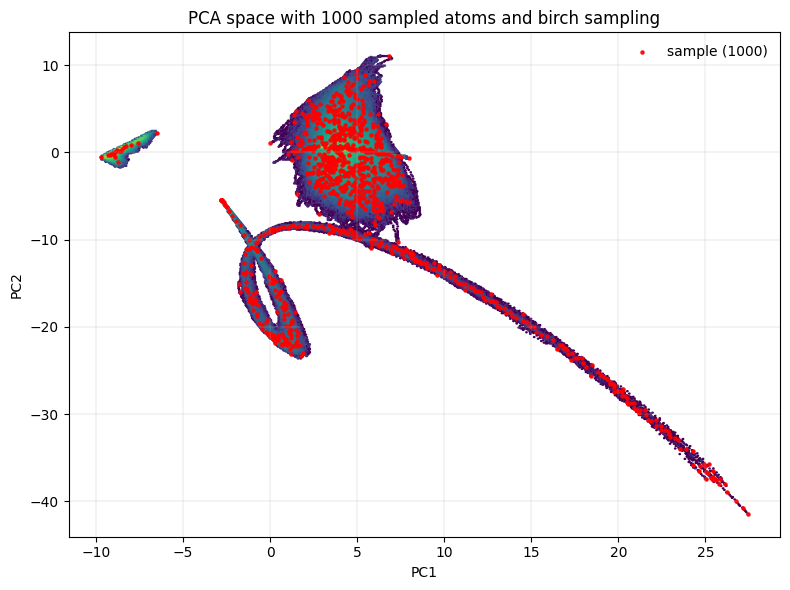

In [13]:
# Guard: only plot if this is a PCA embedding (file name contains "pca")
is_pca = ("pca" in os.path.basename(npy_file).lower()) and (X.shape[1] >= 2)
if not is_pca:
    raise RuntimeError("Plotting requires a 2D+ PCA embedding. Load a PCA .npy first.")

# idx_atoms must come from your sampler, e.g.:
# method = "fps"; idx_atoms = sample(X, method=method, k=1000, progress=True)

fig, ax = plt.subplots(figsize=(8,6))

N = X.shape[0]
if N > 2_000_000:
    # faster background for huge N
    hb = ax.hexbin(X[:,0], X[:,1], gridsize=500, bins='log')
else:
    ax.scatter(X[:,0], X[:,1], s=1, alpha=0.05)

# overlay sampled points
ax.scatter(X[idx,0], X[idx,1], s=5, alpha=0.9, c='r', marker='o', label=f"sample ({len(idx)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA space with {len(idx)} sampled atoms and {method} sampling")
ax.grid(True, linewidth=0.2)
ax.legend(frameon=False, loc="best")
plt.tight_layout()